# YOLO Detection

### Hyperparameters (V2 Improvement)


In [ ]:
yolo_model = "yolo11s.pt"
img_size = TARGET_RES
epochs = 50
batch_size = 8
patience = 10
workers = 8
lr0 = 0.01

conf_default = 0.25
nms_iou = 0.45
max_det = 100

# These HSV values are used only if this notebook trains from scratch
# --> Unused in our implementation --> Future work
hsv_h = 0.0
hsv_s = 0.0
hsv_v = 0.0
fliplr = 0.5
flipud = 0.0
degrees = 0.0
translate = 0.10
scale = 0.50
mosaic = 1.0
close_mosaic = 10

run_name = "member2_yolo11s_thermal_pedestrian"
existing_run_name = "pedestrian_multispectral_yolo11s"
print("YOLO settings are ready.")


YOLO settings are ready.


## Training

### Load or Train YOLOv11s (V2 Improvement)


In [ ]:
existing_checkpoint = results_dir / existing_run_name / "weights" / "best.pt"
new_checkpoint = detection_results_dir / run_name / "weights" / "best.pt"

if existing_checkpoint.exists():
    best_checkpoint_path = existing_checkpoint
    print(f"Using saved YOLO checkpoint: {best_checkpoint_path}")
elif new_checkpoint.exists():
    best_checkpoint_path = new_checkpoint
    print(f"Using notebook-trained YOLO checkpoint: {best_checkpoint_path}")
else:
    best_checkpoint_path = new_checkpoint
    print("No saved YOLO checkpoint found. The next cell will train from scratch.")


Using saved YOLO checkpoint: /home/vteam5/multispectral_pedestrian_ensemble/results/pedestrian_multispectral_yolo11s/weights/best.pt


In [ ]:
do_train = not best_checkpoint_path.exists()

if do_train:
    model = YOLO(yolo_model)
    results = model.train(
        data=str(data_yaml_path),
        imgsz=img_size,
        epochs=epochs,
        batch=batch_size,
        lr0=lr0,
        iou=nms_iou,
        conf=conf_default,
        patience=patience,
        workers=workers,
        hsv_h=hsv_h, hsv_s=hsv_s, hsv_v=hsv_v,
        fliplr=fliplr, flipud=flipud, degrees=degrees,
        translate=translate, scale=scale,
        mosaic=mosaic, close_mosaic=close_mosaic,
        name=run_name,
        project=str(detection_results_dir),
        device=compute_device,
        verbose=True,
    )
    best_checkpoint_path = new_checkpoint
    print(f"Training finished. Best checkpoint: {best_checkpoint_path}")
else:
    print("Training skipped because a checkpoint is already available.")


Training skipped because a checkpoint is already available.


### Training Curves (V2 Improvement)


Loaded training history: /home/vteam5/multispectral_pedestrian_ensemble/results/pedestrian_multispectral_yolo11s/results.csv


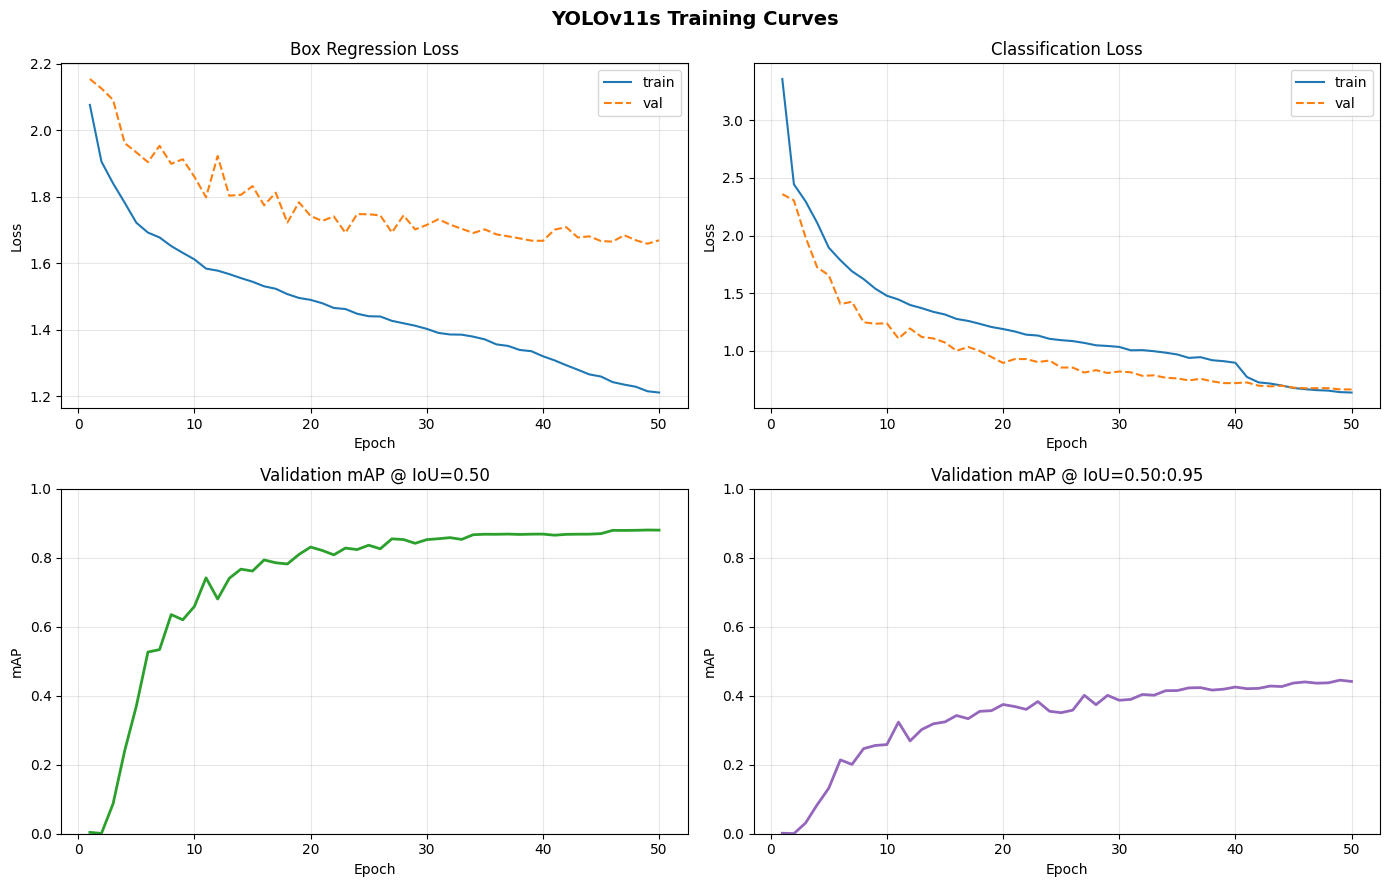

Final epoch: 50
  train/box_loss: 1.2115
  metrics/mAP50(B): 0.8803
  metrics/mAP50-95(B): 0.4415
  metrics/precision(B): 0.9286
  metrics/recall(B): 0.8875
Saved training curves: /home/vteam5/multispectral_pedestrian_ensemble/results_detection/training_curves.png


In [ ]:
candidate_csv_paths = [
    detection_results_dir / run_name / "results.csv",
    results_dir / existing_run_name / "results.csv",
]
results_csv = next((p for p in candidate_csv_paths if p.exists()), None)

if results_csv is None:
    print("Training results.csv was not found, so curves were not plotted.")
else:
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded training history: {results_csv}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("YOLOv11s Training Curves", fontsize=14, fontweight="bold")
    epochs_axis = df["epoch"]

    if "train/box_loss" in df.columns:
        axes[0, 0].plot(epochs_axis, df["train/box_loss"], label="train", color="tab:blue")
        if "val/box_loss" in df.columns:
            axes[0, 0].plot(epochs_axis, df["val/box_loss"], label="val", color="tab:orange", linestyle="--")
        axes[0, 0].set_title("Box Regression Loss")
        axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    if "train/cls_loss" in df.columns:
        axes[0, 1].plot(epochs_axis, df["train/cls_loss"], label="train", color="tab:blue")
        if "val/cls_loss" in df.columns:
            axes[0, 1].plot(epochs_axis, df["val/cls_loss"], label="val", color="tab:orange", linestyle="--")
        axes[0, 1].set_title("Classification Loss")
        axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss")
        axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    if "metrics/mAP50(B)" in df.columns:
        axes[1, 0].plot(epochs_axis, df["metrics/mAP50(B)"], color="tab:green", linewidth=2)
        axes[1, 0].set_title("Validation mAP @ IoU=0.50")
        axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("mAP")
        axes[1, 0].set_ylim(0, 1); axes[1, 0].grid(alpha=0.3)

    if "metrics/mAP50-95(B)" in df.columns:
        axes[1, 1].plot(epochs_axis, df["metrics/mAP50-95(B)"], color="tab:purple", linewidth=2)
        axes[1, 1].set_title("Validation mAP @ IoU=0.50:0.95")
        axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("mAP")
        axes[1, 1].set_ylim(0, 1); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    curves_path = detection_results_dir / "training_curves.png"
    plt.savefig(curves_path, dpi=150, bbox_inches="tight")
    plt.show()

    final = df.iloc[-1]
    print(f"Final epoch: {int(final['epoch'])}")
    for col in ["train/box_loss", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                "metrics/precision(B)", "metrics/recall(B)"]:
        if col in df.columns:
            print(f"  {col}: {final[col]:.4f}")
    print(f"Saved training curves: {curves_path}")


## Confidence Threshold Tuning

### Sweep across thresholds for thermal heat signatures (V2 Improvement)


In [ ]:
def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0


def load_gt(label_path, size):
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().strip().split("\n"):
        if not line.strip():
            continue
        parts = [float(v) for v in line.split()]
        if len(parts) < 5:
            continue
        cx, cy, w, h = parts[1:5]
        boxes.append([(cx - w/2)*size, (cy - h/2)*size, (cx + w/2)*size, (cy + h/2)*size])
    return boxes


In [ ]:
model = YOLO(str(best_checkpoint_path))
val_images = sorted((processed_dataset_dir / "val" / "images").glob("*.jpg"))
val_labels_dir = processed_dataset_dir / "val" / "labels"

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
records = []

for conf in thresholds:
    tp = fp = fn = 0
    total_dets = 0
    print(f"conf {conf:.2f}", end=" ", flush=True)

    for img_path in val_images:
        gt = load_gt(val_labels_dir / (img_path.stem + ".txt"), img_size)
        pred = model.predict(source=str(img_path), conf=conf, iou=nms_iou,
                             imgsz=img_size, verbose=False)
        boxes = pred[0].boxes.xyxy.cpu().numpy().tolist()
        total_dets += len(boxes)

        matched = [False] * len(gt)
        for b in boxes:
            best_iou, best_idx = 0, -1
            for i, g in enumerate(gt):
                if matched[i]:
                    continue
                v = box_iou(b, g)
                if v > best_iou:
                    best_iou, best_idx = v, i
            if best_iou >= 0.5:
                tp += 1
                matched[best_idx] = True
            else:
                fp += 1
        fn += matched.count(False)

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*p*r / (p + r) if (p + r) > 0 else 0
    records.append({"conf": conf, "TP": tp, "FP": fp, "FN": fn,
                    "precision": p, "recall": r, "f1": f1,
                    "det_per_img": total_dets / len(val_images)})
    print(f"P {p:.3f} R {r:.3f} F1 {f1:.3f} det/img {total_dets/len(val_images):.2f}")

sweep_df = pd.DataFrame(records)
confidence_csv_path = detection_results_dir / "confidence_sweep.csv"
sweep_df.to_csv(confidence_csv_path, index=False)
print(sweep_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"Saved confidence sweep: {confidence_csv_path}")


conf 0.10 P 0.673 R 0.729 F1 0.700 det/img 3.03
conf 0.15 P 0.725 R 0.727 F1 0.726 det/img 2.81
conf 0.20 P 0.761 R 0.724 F1 0.742 det/img 2.67
conf 0.25 P 0.793 R 0.721 F1 0.755 det/img 2.55
conf 0.30 P 0.818 R 0.716 F1 0.764 det/img 2.45
conf 0.35 P 0.847 R 0.709 F1 0.772 det/img 2.34
conf 0.40 P 0.879 R 0.702 F1 0.781 det/img 2.24
conf 0.50 P 0.929 R 0.676 F1 0.782 det/img 2.04
  conf   TP   FP   FN  precision  recall     f1  det_per_img
0.1000 3686 1789 1371     0.6732  0.7289 0.7000       3.0349
0.1500 3674 1397 1383     0.7245  0.7265 0.7255       2.8110
0.2000 3659 1151 1398     0.7607  0.7236 0.7417       2.6663
0.2500 3644  951 1413     0.7930  0.7206 0.7551       2.5471
0.3000 3619  803 1438     0.8184  0.7156 0.7636       2.4512
0.3500 3584  645 1473     0.8475  0.7087 0.7719       2.3442
0.4000 3551  490 1506     0.8787  0.7022 0.7806       2.2400
0.5000 3418  263 1639     0.9286  0.6759 0.7823       2.0405
Saved confidence sweep: /home/vteam5/multispectral_pedestrian_ensem

### Plot sweep results (V2 Improvement)


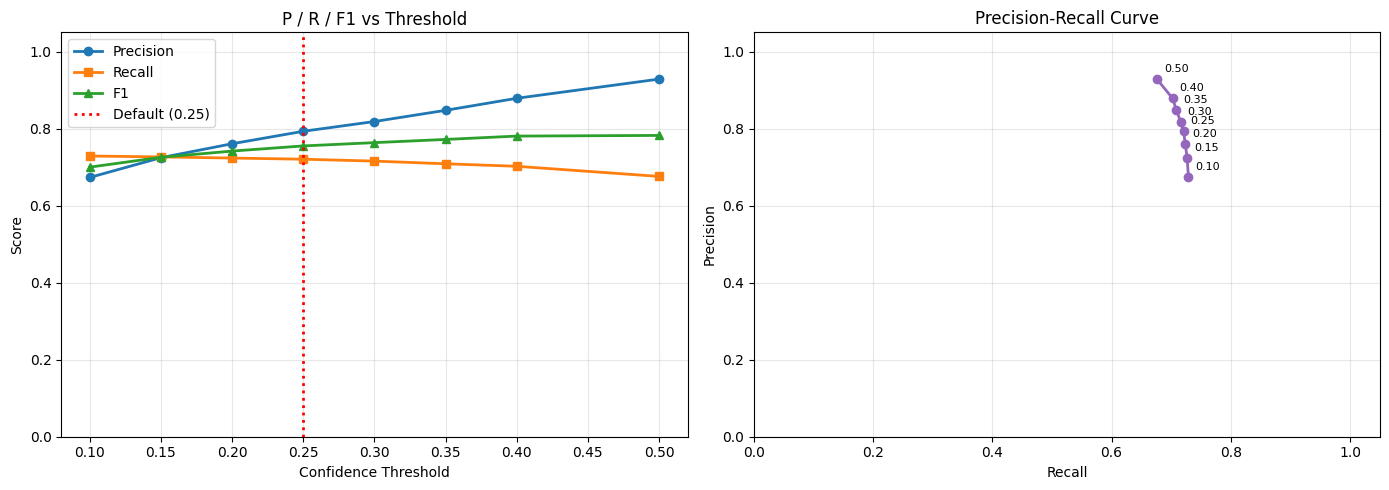

Recommended confidence for the SAM cascade: 0.30
Saved confidence plot: /home/vteam5/multispectral_pedestrian_ensemble/results_detection/confidence_sweep.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sweep_df["conf"], sweep_df["precision"], "o-", label="Precision", linewidth=2)
axes[0].plot(sweep_df["conf"], sweep_df["recall"], "s-", label="Recall", linewidth=2)
axes[0].plot(sweep_df["conf"], sweep_df["f1"], "^-", label="F1", linewidth=2)
axes[0].axvline(conf_default, color="red", linestyle=":", linewidth=2, label=f"Default ({conf_default:.2f})")
axes[0].set_xlabel("Confidence Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("P / R / F1 vs Threshold")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

axes[1].plot(sweep_df["recall"], sweep_df["precision"], "o-", color="tab:purple", linewidth=2)
for _, row in sweep_df.iterrows():
    axes[1].annotate(f"{row['conf']:.2f}", (row["recall"], row["precision"]),
                     fontsize=8, xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
confidence_plot_path = detection_results_dir / "confidence_sweep.png"
plt.savefig(confidence_plot_path, dpi=150, bbox_inches="tight")
plt.show()

best_f1 = sweep_df["f1"].max()
candidates = sweep_df[sweep_df["f1"] >= best_f1 - 0.02]
selected_conf_for_cascade = float(candidates["conf"].min())
print(f"Recommended confidence for the SAM cascade: {selected_conf_for_cascade:.2f}")
print(f"Saved confidence plot: {confidence_plot_path}")


## Validation (V2 Improvement)


In [ ]:
val_model = YOLO(str(best_checkpoint_path))
metrics = val_model.val(
    data=str(data_yaml_path),
    imgsz=img_size,
    conf=conf_default,
    iou=nms_iou,
    device=compute_device,
)

map50 = float(metrics.box.map50)
map50_95 = float(metrics.box.map)
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)

print("YOLO-only validation results")
print(f"mAP@50: {map50:.4f}")
print(f"mAP@50-95: {map50_95:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

yolo_metrics_path = detection_results_dir / "yolo_baseline_metrics.json"
with open(yolo_metrics_path, "w") as f:
    json.dump({
        "model": yolo_model,
        "checkpoint_path": str(best_checkpoint_path),
        "image_size": img_size,
        "confidence_threshold": conf_default,
        "iou_threshold_nms": nms_iou,
        "mAP_at_0.50": map50,
        "mAP_at_0.50_to_0.95": map50_95,
        "precision": precision,
        "recall": recall,
    }, f, indent=2)
print(f"Saved YOLO metrics: {yolo_metrics_path}")


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.6.0+cu124 CUDA:0 (Quadro RTX 4000, 7974MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7641.4±945.0 MB/s, size: 432.9 KB)
val: Scanning /home/vteam5/multispectral_pedestrian_ensemble/processed_dataset/val/labels.cache... 1804 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1804/1804 540.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 3.3it/s 33.8s
                   all       1804       5057      0.927      0.888      0.881      0.445
Speed: 1.2ms preprocess, 15.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/vteam5/sam2/runs/detect/val-8
YOLO-only validation results
mAP@50: 0.8805
mAP@50-95: 0.4449
Precision: 0.9268
Recall: 0.8877
Saved YOLO metrics: /home/vteam5/multispectral_pedestrian_ensemble/results_detection/yolo_baseline_metrics.json

## Qualitative Samples (V2 Improvement)


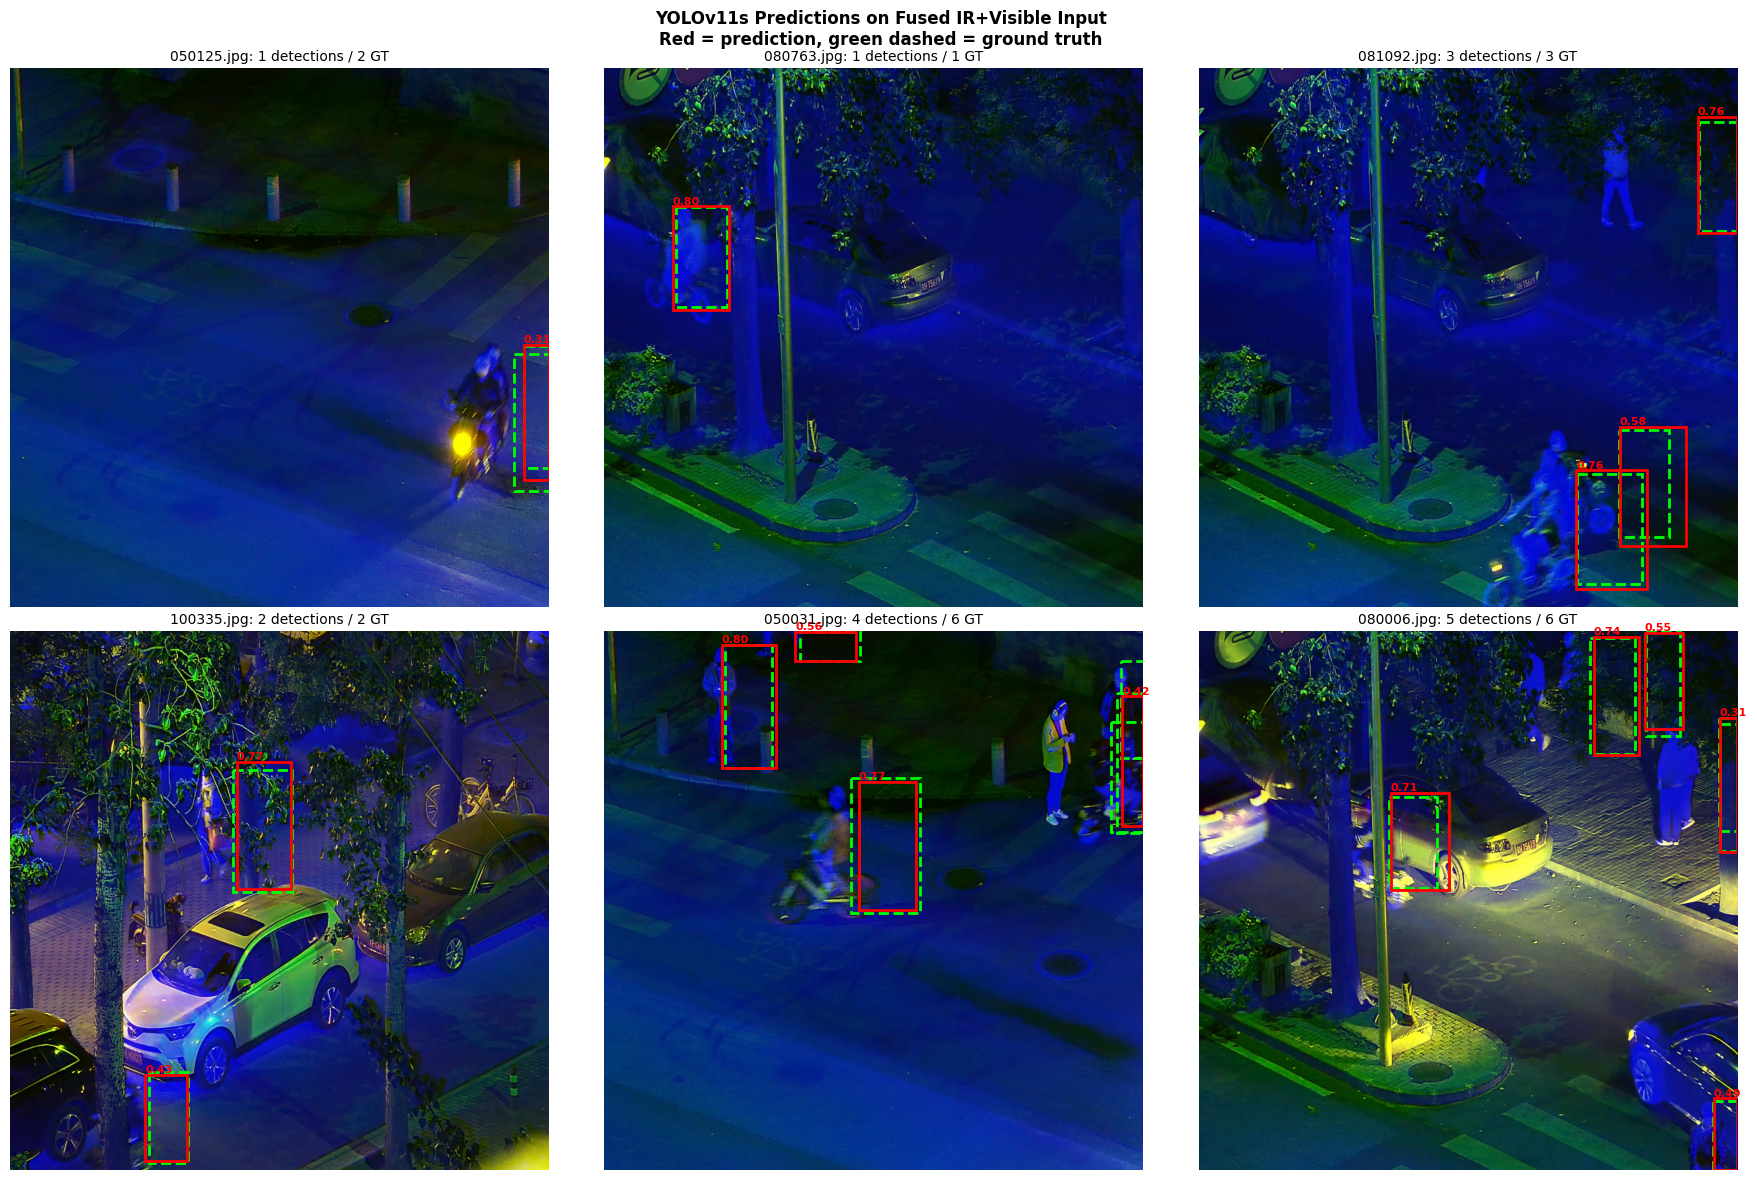

Saved YOLO qualitative samples: /home/vteam5/multispectral_pedestrian_ensemble/results_detection/qualitative_samples.png


In [ ]:
sample_indices = random.sample(range(len(val_images)), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("YOLOv11s Predictions on Fused IR+Visible Input\nRed = prediction, green dashed = ground truth",
             fontsize=12, fontweight="bold")
axes_flat = axes.flatten()

q_model = YOLO(str(best_checkpoint_path))

for pos, idx in enumerate(sample_indices):
    img_path = val_images[idx]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    pred = q_model.predict(source=str(img_path), conf=conf_default, iou=nms_iou,
                           imgsz=img_size, verbose=False)
    boxes = pred[0].boxes.xyxy.cpu().numpy()
    confs = pred[0].boxes.conf.cpu().numpy()
    gt = load_gt(val_labels_dir / (img_path.stem + ".txt"), img_size)

    axes_flat[pos].imshow(img)
    for g in gt:
        rect = patches.Rectangle((g[0], g[1]), g[2]-g[0], g[3]-g[1],
                                 linewidth=2, edgecolor="lime", linestyle="--", facecolor="none")
        axes_flat[pos].add_patch(rect)
    for b, c in zip(boxes, confs):
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                 linewidth=2, edgecolor="red", facecolor="none")
        axes_flat[pos].add_patch(rect)
        axes_flat[pos].text(b[0], b[1]-5, f"{c:.2f}", color="red",
                            fontsize=8, fontweight="bold")
    axes_flat[pos].set_title(f"{img_path.name}: {len(boxes)} detections / {len(gt)} GT", fontsize=10)
    axes_flat[pos].axis("off")

plt.tight_layout()
yolo_samples_path = detection_results_dir / "qualitative_samples.png"
plt.savefig(yolo_samples_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved YOLO qualitative samples: {yolo_samples_path}")


## Bridge Export to SAM 2 (V2 Improvement)


### Save bbox detections in xyxy absolute pixels (V2 Improvement)


In [ ]:
export_model = YOLO(str(best_checkpoint_path))
export_dict = {
    "metadata": {
        "model": yolo_model,
        "checkpoint_path": str(best_checkpoint_path),
        "image_size": img_size,
        "confidence_threshold": conf_default,
        "iou_threshold_nms": nms_iou,
        "max_detections": max_det,
        "format": "xyxy_absolute_pixels",
        "num_images": len(val_images),
    },
    "detections": {},
}

total = 0
zero_count = 0
for i, img_path in enumerate(val_images):
    out = export_model.predict(source=str(img_path), conf=conf_default, iou=nms_iou,
                               imgsz=img_size, max_det=max_det, verbose=False)
    boxes = out[0].boxes.xyxy.cpu().numpy()
    confs = out[0].boxes.conf.cpu().numpy()

    export_dict["detections"][img_path.name] = {
        "image_size_hw": [img_size, img_size],
        "boxes_xyxy": boxes.round(2).tolist(),
        "confidences": confs.round(4).tolist(),
    }
    total += len(boxes)
    if len(boxes) == 0:
        zero_count += 1
    if (i + 1) % 200 == 0:
        print(f"{i+1}/{len(val_images)} images exported")

bridge_path = detection_results_dir / "yolo_detections.json"
with open(bridge_path, "w") as f:
    json.dump(export_dict, f, indent=2)

print("Bridge export complete")
print(f"Images: {len(val_images)}")
print(f"Detections: {total}")
print(f"Zero-detection images: {zero_count}")
print(f"Average detections per image: {total/len(val_images):.2f}")
print(f"Saved bridge file: {bridge_path}")


200/1804 images exported
400/1804 images exported
600/1804 images exported
800/1804 images exported
1000/1804 images exported
1200/1804 images exported
1400/1804 images exported
1600/1804 images exported
1800/1804 images exported
Bridge export complete
Images: 1804
Detections: 4595
Zero-detection images: 41
Average detections per image: 2.55
Saved bridge file: /home/vteam5/multispectral_pedestrian_ensemble/results_detection/yolo_detections.json


### SAM 2 Format Moving Downstream

```python
with open("yolo_detections.json") as f:
    bridge = json.load(f)

rec = bridge["detections"]["010001.jpg"]
boxes = np.array(rec["boxes_xyxy"])

sam2_pred.set_image(visible_rgb)
masks, iou_scores, _ = sam2_pred.predict(
    point_coords=None,
    point_labels=None,
    box=boxes,
    multimask_output=True,
)
```


## YOLO Detection Summary (V2 Improvement)


In [ ]:
print("YOLO detection summary")
print(f"Model: {yolo_model}")
print(f"Image size: {img_size}")
print(f"Confidence: {conf_default}")
print(f"NMS IoU: {nms_iou}")
print(f"mAP@50: {map50:.4f}")
print(f"mAP@50-95: {map50_95:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("Saved YOLO artifacts")
for p in sorted(detection_results_dir.rglob("*")):
    if p.is_file() and p.suffix in (".csv", ".json", ".png"):
        print(f"  {p.relative_to(detection_results_dir)} ({p.stat().st_size/1e6:.2f} MB)")


YOLO detection summary
Model: yolo11s.pt
Image size: 1024
Confidence: 0.25
NMS IoU: 0.45
mAP@50: 0.8805
mAP@50-95: 0.4449
Precision: 0.9268
Recall: 0.8877
Saved YOLO artifacts
  confidence_sweep.csv (0.00 MB)
  confidence_sweep.png (0.08 MB)
  qualitative_samples.png (5.54 MB)
  training_curves.png (0.16 MB)
  yolo_baseline_metrics.json (0.00 MB)
  yolo_detections.json (1.00 MB)
